# Merge Hourly Weather Data

- starting point: files downloaded with script `01_fetch_weather_data_DWD.ipynb`
    - [hourly data](https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/hourly/) downloaded from Deutscher Wetterdienst (DWD)
- organization of data files:
    - multiple parameters measured - stored as separate files
    - mostly: two files per parameter (recent & historical data)
        - time overlap between files leads to duplicates in the data
    - separate files for each weather station (location)
- task:
    - select a target weather station of interest (e.g. Goerlitz or Konstanz)
    - concatenate both files for each parameter
    - merge all dataframes with the different variables by datetime information
    - delete duplicate rows and columns
    - rename columns
    - drop uninformative columns
    - export resulting dataframe as csv file

## Hourly DWD Data

[available data](https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/hourly/)

dir | acronym
--- | ---
solar | ST (just 1 dir)
sun | SD
visibility | VV
cloud_type | CS
cloudiness | N
weather_phenomena | WW
wind | FF
wind_synop | F
extreme_wind | FX
precipitation | RR
|
dew_point | TD
moisture | TF
air_temperature | TU
soil_temperature | EB
pressure | P0

## Preparation

In [1]:
# load packages
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

target_dwd_weather_station_id = "02712"

## Identify Data Files

1. Identify Data Directories
    - separate subdirectory per weather parameter and timeframe (recent/historical)
2. Identify files for target weather station

In [2]:
# relative path to hourly dwd weather data
path = "../data/weather/weather-hourly/"


In [3]:
# list of directories 
# os.walk yields [0] path, [1] directories, [2] files
dirs = list(os.walk(path))[0][1]

# store all target files in list of tuples (folder, filename)
file_collection = []
for folder in dirs:
    files = list(os.walk(path+folder+"/"))[0][2]
    for filename in files:
        if target_dwd_weather_station_id in filename:
            # print(file)
            file_collection.append((folder, filename))
            if not filename.split(".")[0].endswith(target_dwd_weather_station_id):
                print("Check file %d - ID might match the date!" % filename)
print(len(file_collection), "files for DWD weather station", target_dwd_weather_station_id)
print(file_collection)

29 files for DWD weather station 02712
[('FX_extreme_wind_historical', 'produkt_fx_stunde_19900705_20221231_02712.txt'), ('F_wind_synopsis_recent', 'produkt_f_stunde_20220123_20230726_02712.txt'), ('FF_wind_recent', 'produkt_ff_stunde_20220123_20230726_02712.txt'), ('CS_cloud_type_recent', 'produkt_cs_stunde_20220123_20230726_02712.txt'), ('FF_wind_historical', 'produkt_ff_stunde_19590701_20221231_02712.txt'), ('VV_visibility_historical', 'produkt_vv_stunde_19520102_20221231_02712.txt'), ('TD_dewpoint_recent', 'produkt_td_stunde_20220123_20230726_02712.txt'), ('CS_cloud_type_historical', 'produkt_cs_stunde_19520101_20221231_02712.txt'), ('TU_temp_air_recent', 'produkt_tu_stunde_20220123_20230726_02712.txt'), ('FX_extreme_wind_recent', 'produkt_fx_stunde_20220123_20230726_02712.txt'), ('TF_moisture_recent', 'produkt_tf_stunde_20220123_20230726_02712.txt'), ('TF_moisture_historical', 'produkt_tf_stunde_19520502_20221231_02712.txt'), ('VV_visibility_recent', 'produkt_vv_stunde_20220123_20

### File-specific issues
CS_cloud_type_historical
- `DtypeWarning: Columns (6,10,14,18) have mixed types.` Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path+folder+"/"+file, sep=";", encoding='unicode_escape')


WW_weather_phenomena_recent: 
- `UnicodeDecodeError: 'utf-8' codec can't decode byte 0xf6 in position 924: invalid start byte`  
    - use `encoding='unicode_escape'`
- `ParserError: Error tokenizing data. C error: Expected 1 fields in line 48, saw 2`  
    - specify `sep=";"`

ST_solar_hourly
- `ValueError: time data "1977010100:26" doesn't match format "%Y%m%d%H:%%", at position 0.` You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.


## Read Files into Dataframes

In [4]:
# read all files into separate dataframes
# immediately drop unnecessary columns (id, eor, qn)
# also convert date into datetime format
df_collection = []
df_index = {}
idx = 0
for folder, file in file_collection:
    print("\n"+folder, end=" - ")
    # try to read files
    try:
        df = pd.read_csv(path+folder+"/"+file, sep=";", encoding='unicode_escape')
    except:
        idx = 0
        for line in open(path+folder+"/"+file, encoding="unicode_escape"):
            print(idx, line.strip())
            idx += 1
            if idx == 50:
                break
        # df = pd.read_csv(path+folder+"/"+file, sep=";", 
        #                  encoding='unicode_escape', error_bad_lines=False)
    
    # drop unnecessary columns on ID (all identical) and eor
    df.drop(columns=["STATIONS_ID", "eor"], inplace=True)
    qn_columns = list(df.columns[df.columns.str.contains('qn', case=False)])
    # drop unnecessary quality columns (QNx)
    if len(qn_columns) != 0:
        df.drop(columns=qn_columns, inplace=True)
        print(list(df.columns), "- dropped", qn_columns)
    else:
        print(list(df.columns))

    # strip spaces from column names
    df.columns = [x.strip() for x in df.columns]

    # convert date column into datetime format
    try:
        df.MESS_DATUM = pd.to_datetime(df['MESS_DATUM'], format='%Y%m%d%H')
    except:
        # print(df.head(2), "\n")
        remainders = set([x.split(":")[-1] for x in df.MESS_DATUM])
        print("\tRemainders found in date column:", ", ".join(sorted(remainders)))
        df.MESS_DATUM = [x.split(":")[0] for x in df.MESS_DATUM]
        df.MESS_DATUM = pd.to_datetime(df['MESS_DATUM'], format='%Y%m%d%H')
    
    # store information on linked recent & historical files
    df_collection.append(df)
    if "recent" in folder:
        topic = folder.replace("_recent", "")
        tag = "recent"
    elif "historical" in folder:
        topic = folder.replace("_historical", "")
        tag = "historical"
    else: # ST has only one file!
        tag = "historical"
        topic = folder
        print(folder, "is neither recent nor historical")
    # store file indices in nested dictionary by topic and time window
    if not topic in df_index.keys():
        df_index[topic] = {tag: idx}
    else:
        df_index[topic][tag] = idx
    idx += 1



FX_extreme_wind_historical - ['MESS_DATUM', 'FX_911'] - dropped ['QN_8']

F_wind_synopsis_recent - ['MESS_DATUM', '  FF', '  DD'] - dropped ['QN_8']

FF_wind_recent - ['MESS_DATUM', '   F', '   D'] - dropped ['QN_3']

CS_cloud_type_recent - ['MESS_DATUM', ' V_N', 'V_N_I', 'V_S1_CS', 'V_S1_CSA', 'V_S1_HHS', 'V_S1_NS', 'V_S2_CS', 'V_S2_CSA', 'V_S2_HHS', 'V_S2_NS', 'V_S3_CS', 'V_S3_CSA', 'V_S3_HHS', 'V_S3_NS', 'V_S4_CS', 'V_S4_CSA', 'V_S4_HHS', 'V_S4_NS'] - dropped ['QN_8']

FF_wind_historical - ['MESS_DATUM', '   F', '   D'] - dropped ['QN_3']

VV_visibility_historical - ['MESS_DATUM', 'V_VV_I', 'V_VV'] - dropped ['QN_8']

TD_dewpoint_recent - ['MESS_DATUM', '  TT', '  TD'] - dropped ['QN_8']

CS_cloud_type_historical - 

/var/folders/7l/jfv_5v6d6b9gm5rq3d9zbm9w0000gn/T/ipykernel_7932/3884937286.py:11: DtypeWarning: Columns (6,10,14,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path+folder+"/"+file, sep=";", encoding='unicode_escape')


['MESS_DATUM', ' V_N', 'V_N_I', 'V_S1_CS', 'V_S1_CSA', 'V_S1_HHS', 'V_S1_NS', 'V_S2_CS', 'V_S2_CSA', 'V_S2_HHS', 'V_S2_NS', 'V_S3_CS', 'V_S3_CSA', 'V_S3_HHS', 'V_S3_NS', 'V_S4_CS', 'V_S4_CSA', 'V_S4_HHS', 'V_S4_NS'] - dropped ['QN_8']

TU_temp_air_recent - ['MESS_DATUM', 'TT_TU', 'RF_TU'] - dropped ['QN_9']

FX_extreme_wind_recent - ['MESS_DATUM', 'FX_911'] - dropped ['QN_8']

TF_moisture_recent - ['MESS_DATUM', 'ABSF_STD', 'VP_STD', 'TF_STD', 'P_STD', 'TT_STD', 'RF_STD', 'TD_STD'] - dropped ['QN_8']

TF_moisture_historical - ['MESS_DATUM', 'ABSF_STD', 'VP_STD', 'TF_STD', 'P_STD', 'TT_STD', 'RF_STD', 'TD_STD'] - dropped ['QN_8']

VV_visibility_recent - ['MESS_DATUM', 'V_VV_I', 'V_VV'] - dropped ['QN_8']

WW_weather_phenomena_recent - ['MESS_DATUM', '  WW', 'WW_Text'] - dropped ['QN_8']

EB_temp_soil_historical - ['MESS_DATUM', 'V_TE002', 'V_TE005', 'V_TE010', 'V_TE020', 'V_TE050', 'V_TE100'] - dropped ['QN_2']

N_cloudiness_historical - ['MESS_DATUM', 'V_N_I', ' V_N'] - dropped ['QN_8'

## Create Complete Dataframe

1. concatenate both files for each weather parameter
    - combine recent + historical data
    - drop duplicates
>
2. join different features by date as additional columns
    - drop duplicate columns
>
3. refine dataframe
    - rename columns
    - drop unnecessary columns

### Concatenate Recent & Historical Data

In [5]:
def concat_dfs(df1, df2, remove_dupl=True, unique_cols=[]):
    """concatenate two dataframes, reindex them and (optionally) remove duplicates

    Args:
        df1 (pd.df): 1st dataframe
        df2 (pd.df): 1st dataframe
        remove_dupl (bool, optional): option to automatically drop duplicates. Defaults to True.
        unique_cols (list, optional): columns to ignore when removing duplicates. Defaults to [].

    Returns:
        _type_: _description_
    """

    # require column names to match
    if any(df1.columns != df2.columns):
        print("Attention! Headers don't match!")
        print("DF1 headers:", ", ".join(df1.columns))
        print("DF2 headers:", ", ".join(df2.columns))
        print("Not merging DFs!")
        return 

    print("Concatenating %d and %d rows." % (df1.shape[0], df2.shape[0]))

    # concatenate both dataframes
    full_df = pd.concat([df1, df2], axis=0)
    full_df.reset_index(inplace=True, drop=True)
    
    if remove_dupl:
        # check for duplicates
        if not True in full_df.MESS_DATUM.duplicated().value_counts(): 
            print("No duplicates found")
        else:
            print(full_df.MESS_DATUM.duplicated().value_counts()[True], "duplicates found!")
            l1 = full_df.shape[0] # df length
        
            # drop duplicates (only unique_cols may differ, e.g. index)
            full_df.drop_duplicates(ignore_index=True, inplace=True, 
                                    subset=full_df.columns.difference(unique_cols))
            full_df.reset_index(inplace=True, drop=True)
            l2 = full_df.shape[0] # df length without duplicates

            # check for remaining duplicates
            if True in full_df.MESS_DATUM.duplicated().value_counts():
                print("%d duplicates removed, but %d remaining!" % \
                      (l1-l2, full_df.MESS_DATUM.duplicated().value_counts()[True]))
                print("Columns:", df1.columns)
                print(full_df[full_df.MESS_DATUM.duplicated()].head())
            else:
                print("All %d duplicates removed" % (l1-l2))
        print("Final length of merged dataframe:", l2, "\n")
    
    return full_df

In [6]:
# merge historic and recent dataframes into one for each topic separately
df_collection_topicwise = []
for topic in sorted(df_index.keys()):
    # extract indices of recent and historical dataframes
    df_idx = df_index[topic]['historical']
    print(topic, df_idx)
    if "recent" in df_index[topic].keys():
        df_jdx = df_index[topic]['recent']
    else:
        df_jdx = None
    
    # extract recent dataframe
    df = df_collection[df_idx]

    # add historical data (if present) and remove duplicated rows
    if df_jdx != None:
        df2 = df_collection[df_jdx]
        df = concat_dfs(df, df2)
    else:
        print("No merging required.\n")
    
    # store merged dataframe in list
    df_collection_topicwise.append(df)


CS_cloud_type 7
Concatenating 440814 and 13199 rows.
8231 duplicates found!
All 8231 duplicates removed
Final length of merged dataframe: 445782 

EB_temp_soil 14
Concatenating 218002 and 13200 rows.
8232 duplicates found!
All 8232 duplicates removed
Final length of merged dataframe: 222970 

FF_wind 4
Concatenating 556395 and 13200 rows.
8232 duplicates found!
All 8232 duplicates removed
Final length of merged dataframe: 561363 

FX_extreme_wind 0
Concatenating 191960 and 13200 rows.
8232 duplicates found!
All 8232 duplicates removed
Final length of merged dataframe: 196928 

F_wind_synopsis 17
Concatenating 441512 and 13200 rows.
8232 duplicates found!
All 8232 duplicates removed
Final length of merged dataframe: 446480 

N_cloudiness 15
Concatenating 440780 and 13198 rows.
8230 duplicates found!
All 8230 duplicates removed
Final length of merged dataframe: 445748 

P0_pressure 18
Concatenating 438790 and 13200 rows.
8232 duplicates found!
All 8232 duplicates removed
Final length of 

In [7]:
print(len(df_collection_topicwise), "weather parameters processed for DWD weather station", 
      target_dwd_weather_station_id)

15 weather parameters processed for DWD weather station 02712


### Merge Weather Parameters

In [8]:
# merge dataframes into one
df_weather = pd.DataFrame(df_collection_topicwise[0].MESS_DATUM)
idx = 0
for df in df_collection_topicwise[0:]:
    # print("->", df_weather.columns)
    print("Adding %s:" % (sorted(df_index.keys())[idx]), list(df.columns))
    for item in list(df.columns):
        if item in df_weather.columns.drop("MESS_DATUM"):
            print("  Duplicate column '%s'" % (item))
    # df_weather.join(df, how="outer", on=["MESS_DATUM"])
    df_weather = pd.merge(df_weather, df, on=['MESS_DATUM'], how="outer")
    idx += 1
print("\n-> %d Columns: %s" % (len(df_weather.columns), ", ".join(df_weather.columns)))


Adding CS_cloud_type: ['MESS_DATUM', 'V_N', 'V_N_I', 'V_S1_CS', 'V_S1_CSA', 'V_S1_HHS', 'V_S1_NS', 'V_S2_CS', 'V_S2_CSA', 'V_S2_HHS', 'V_S2_NS', 'V_S3_CS', 'V_S3_CSA', 'V_S3_HHS', 'V_S3_NS', 'V_S4_CS', 'V_S4_CSA', 'V_S4_HHS', 'V_S4_NS']
Adding EB_temp_soil: ['MESS_DATUM', 'V_TE002', 'V_TE005', 'V_TE010', 'V_TE020', 'V_TE050', 'V_TE100']
Adding FF_wind: ['MESS_DATUM', 'F', 'D']
Adding FX_extreme_wind: ['MESS_DATUM', 'FX_911']
Adding F_wind_synopsis: ['MESS_DATUM', 'FF', 'DD']
Adding N_cloudiness: ['MESS_DATUM', 'V_N_I', 'V_N']
  Duplicate column 'V_N_I'
  Duplicate column 'V_N'
Adding P0_pressure: ['MESS_DATUM', 'P', 'P0']
Adding RR_precipitation: ['MESS_DATUM', 'R1', 'RS_IND', 'WRTR']
Adding SD_sun_hourly: ['MESS_DATUM', 'SD_SO']
Adding ST_solar_hourly: ['MESS_DATUM', 'ATMO_LBERG', 'FD_LBERG', 'FG_LBERG', 'SD_LBERG', 'ZENIT', 'MESS_DATUM_WOZ']
Adding TD_dewpoint: ['MESS_DATUM', 'TT', 'TD']
Adding TF_moisture: ['MESS_DATUM', 'ABSF_STD', 'VP_STD', 'TF_STD', 'P_STD', 'TT_STD', 'RF_STD', '

In [9]:
df_weather.shape

(575027, 59)

### Refine Dataframe

In [10]:
# # drop duplicate columns (takes 7 minutes)
# orig_columns = df_weather.columns
# df_weather = df_weather.T.drop_duplicates().T
# print("Dropped columns:", set(orig_columns).difference(set(df_weather.columns)))
# df_weather.shape

In [11]:
print("Remaining columns:\n", df_weather.columns)

Remaining columns:
 Index(['MESS_DATUM', 'V_N_x', 'V_N_I_x', 'V_S1_CS', 'V_S1_CSA', 'V_S1_HHS',
       'V_S1_NS', 'V_S2_CS', 'V_S2_CSA', 'V_S2_HHS', 'V_S2_NS', 'V_S3_CS',
       'V_S3_CSA', 'V_S3_HHS', 'V_S3_NS', 'V_S4_CS', 'V_S4_CSA', 'V_S4_HHS',
       'V_S4_NS', 'V_TE002', 'V_TE005', 'V_TE010', 'V_TE020', 'V_TE050',
       'V_TE100', 'F', 'D', 'FX_911', 'FF', 'DD', 'V_N_I_y', 'V_N_y', 'P',
       'P0', 'R1', 'RS_IND', 'WRTR', 'SD_SO', 'ATMO_LBERG', 'FD_LBERG',
       'FG_LBERG', 'SD_LBERG', 'ZENIT', 'MESS_DATUM_WOZ', 'TT', 'TD',
       'ABSF_STD', 'VP_STD', 'TF_STD', 'P_STD', 'TT_STD', 'RF_STD', 'TD_STD',
       'TT_TU', 'RF_TU', 'V_VV_I', 'V_VV', 'WW', 'WW_Text'],
      dtype='object')


### Rename Columns

- available columns (description from respective PDF file, one per weather parameter)
- more information on column names [here](https://opendata.dwd.de/climate_environment/CDC/help/Abkuerzung_Spaltenname_CDC_20180914.xlsx)



In [12]:
# original column names
df_weather.columns

Index(['MESS_DATUM', 'V_N_x', 'V_N_I_x', 'V_S1_CS', 'V_S1_CSA', 'V_S1_HHS',
       'V_S1_NS', 'V_S2_CS', 'V_S2_CSA', 'V_S2_HHS', 'V_S2_NS', 'V_S3_CS',
       'V_S3_CSA', 'V_S3_HHS', 'V_S3_NS', 'V_S4_CS', 'V_S4_CSA', 'V_S4_HHS',
       'V_S4_NS', 'V_TE002', 'V_TE005', 'V_TE010', 'V_TE020', 'V_TE050',
       'V_TE100', 'F', 'D', 'FX_911', 'FF', 'DD', 'V_N_I_y', 'V_N_y', 'P',
       'P0', 'R1', 'RS_IND', 'WRTR', 'SD_SO', 'ATMO_LBERG', 'FD_LBERG',
       'FG_LBERG', 'SD_LBERG', 'ZENIT', 'MESS_DATUM_WOZ', 'TT', 'TD',
       'ABSF_STD', 'VP_STD', 'TF_STD', 'P_STD', 'TT_STD', 'RF_STD', 'TD_STD',
       'TT_TU', 'RF_TU', 'V_VV_I', 'V_VV', 'WW', 'WW_Text'],
      dtype='object')

old title | new title | description | unit
--- | --- | --- | ---
MESS_DATUM | date | reference date | -
MESS_DATUM_WOZ |  | local true solar time | -
|||
SD_SO |  | hourly sunshine duration | min
ZENIT |  | solar zenith angle at mid of interval - solar zenith angle 0-180, defined as: ZENIT=90-solar_height | °
|||
F |  | windspeed | m/s
D |  | winddirection | °
FF |  | windspeed synopsis | m/s
DD |  | winddirection synopsis | °
FX_911 |  | windspeed, windgust | m/s
|||
R1 |  | precipitation | mm
RS_IND |  | precipitation indicator (0=no, 1=yes) | -
WRTR |  | precipitation form (0=No precipitation,9=Missing, precipitation type unascertainable, 8=Liquid & solid precipitation, 7=Solid precipitation, 6=Liquid precipitation,4=Type unascertainable and depositional precipitation, 1=precipitation only [<1979]) | -
|||
ATMO_LBERG |  | longwave downward radiation | J/cm^2
FD_LBERG |  | hourly sum of diffuse solar radiation | J/cm^2
FG_LBERG |  | solar incoming radiation (includes direct & diffuse solar radiation with respect to horizontal plane,  sometimes referred to as shortwave, including the solar spectrum up to 2.8 micron, as opposed to longwave, which refers to thermal radiation of the atmosphere) | J/cm^2
SD_LBERG |  | hourly sum of sunshine duration | min
|||
V_VV |  | visibility range | m
V_VV_I |  | visibility index, how the measurement is taken (P=human,I=instrument) | -
|||
WW_Text |  | weather description | -
WW |  | weather code | -
|||
V_N |  | total cloud cover | 1/8
V_N_I |  | how measurement was taken (P=human, I=instrument) | - 
V_S1_CS |  | cloud type of 1. layer | -
V_S2_CS |  | cloud type of 2. layer | -
V_S3_CS |  | cloud type of 3. layer | -
V_S4_CS |  | cloud type of 4. layer | -
V_S1_CSA |  | abbrev. cloud type 1. layer | -
V_S2_CSA |  | abbrev. cloud type 2. layer | -
V_S3_CSA |  |  abbrev. cloud type 3. layer | - 
V_S4_CSA |  | abbrev. cloud type 4. layer | -
V_S1_HHS |  | lower boundary height of 1. layer | m
V_S2_HHS |  | lower boundary height of 2. layer | m
V_S3_HHS |  | lower boundary height of 3. layer | m
V_S4_HHS |  | lower boundary height of 4.layer | m
V_S1_NS |  | cloud cover of 1. layer | 1/8
V_S2_NS |  | cloud cover of 2. layer | 1/8
V_S3_NS |  | cloud cover of 3. layer | 1/8
V_S4_NS |  | cloud cover of 4. layer | 1/8
|||
V_TE002 |  | soil temperature in 2 cm depth | °C
V_TE005 |  | soil temperature in 5 cm depth | °C
V_TE010 |  | soil temperature in 10 cm depth | °C
V_TE020 |  | soil temperature in 20 cm depth | °C
V_TE050 |  | soil temperature in 50 cm depth | °C
V_TE100 |  | soil temperature in 100 cm depth | °C
|||
TT |  | air temperature | °C
TD |  | dew point temperature | °C
|||
TT_TU |  | air temperature | °C
RF_TU |  | relative humidity | %
|||
P |  | Barometric pressure at sea level NN | hPa
P0 |  | Barometric pressure at station height | hPa
||| 
ABSF_STD |  | berechnete Stundenwerte der absoluten Feuchte | g/m^3
VP_STD |  | berechnete Stundenwerte des Dampfdruckes | hPa
TF_STD |  | berechnete Stundenwerte der Feuchttemperatur | °C 
P_STD |  | Stundenwerte Luftdruck | hPa (dupl removed!)
TT_STD |  | Lufttemperatur in 2m Hoehe | °C (dupl removed!)
RF_STD |  | Stundenwerte der relativen Feuchte | % 
TD_STD |  | Taupunkttemperatur in 2m Hoehe | °C


In [13]:
# rename columns
df_weather.columns

rename_dict = {
    "MESS_DATUM": "date", # as daily
    "MESS_DATUM_WOZ": "date_solar_time",

    "SD_SO": "sunshine_duration", # as daily
    "ZENIT": "zenit",

    "F": "wind_speed", # similar to daily
    "D": "wind_direct", 
    "FF": "wind_speed_synopsis", 
    "DD": "wind_direct_synopsis", 
    "FX_911": "wind_gust", # similar to daily

    "R1": "precipitation_height", # as daily
    "RS_IND": "precipitation_info", 
    "WRTR": "precipitation_form", # as daily

    "V_N_x": "cloud_cover", # as daily
    "V_N_I_x": "cloud_cover_info", 
    "V_N_y": "cloud_cover_y", 
    "V_N_I_y": "cloud_cover_info_y", 

    "ATMO_LBERG": "radiation_longwave", 
    "FD_LBERG": "radiation_sum_diffuse", 
    "FG_LBERG": "radiation_shortwave", 
    "SD_LBERG": "sunshine_duration_lberg", 

    "V_VV": "vis_range", 
    "V_VV_I": "vis_range_info", 
    
    "WW": "weather_code", 
    "WW_Text": "weather_descript", 

    "V_S1_CS": "cloud_type_layer1", 
    "V_S2_CS": "cloud_type_layer2", 
    "V_S3_CS": "cloud_type_layer3", 
    "V_S4_CS": "cloud_type_layer4", 
    "V_S1_CSA": "cloud_type_layer1_abbrev", 
    "V_S2_CSA": "cloud_type_layer2_abbrev", 
    "V_S3_CSA": "cloud_type_layer3_abbrev", 
    "V_S4_CSA": "cloud_type_layer4_abbrev", 
    "V_S1_HHS": "cloud_lower_boundary_height_layer1", 
    "V_S2_HHS": "cloud_lower_boundary_height_layer2", 
    "V_S3_HHS": "cloud_lower_boundary_height_layer3", 
    "V_S4_HHS": "cloud_lower_boundary_height_layer4", 
    "V_S1_NS": "cloud_cover_layer1", 
    "V_S2_NS": "cloud_cover_layer2", 
    "V_S3_NS": "cloud_cover_layer3", 
    "V_S4_NS": "cloud_cover_layer4", 

    "TT": "temp_air", 
    "TD": "temp_dew_point", 
    "TT_TU": "temp_air2", # removed manually (one value differs)
    "RF_TU": "humidity_rel", 

    "V_TE002": "temp_soil_002cm", 
    "V_TE005": "temp_soil_005cm", 
    "V_TE010": "temp_soil_010cm", 
    "V_TE020": "temp_soil_020cm", 
    "V_TE050": "temp_soil_050cm", 
    "V_TE100": "temp_soil_100cm", 
    "P": "pressure_sea_level", 
    "P0": "pressure_station_level", 
    "ABSF_STD": "abs_humidity", 
    "VP_STD": "vapor_pressure", 
    "TF_STD": "temp_humid", 
    "RF_STD": "rel_humidity", 
    "TD_STD": "dew_point_2m", 
    "TT_STD": "temp_air_2m", # removed
    "P_STD": "pressure_air", # removed

    # # missing in hourly data - 
    # "SHK_TAG": "snow_depth", # as daily
    # "PM": "mean_pressure", # as daily
    # "VPM": "mean_vapor_pressure", # as daily
    # "UPM": "mean_relative_humidity", # as daily
    # "TMK": "mean_temperature", # as daily
    # "TXK": "max_temperature", # as daily
    # "TNK": "min_temperature", # as daily
    # "TGK": "min_air_temperature" # as daily
}

# Rename columns
df_weather.rename(columns=rename_dict, inplace=True)


In [14]:
# new column names
df_weather.columns


Index(['date', 'cloud_cover', 'cloud_cover_info', 'cloud_type_layer1',
       'cloud_type_layer1_abbrev', 'cloud_lower_boundary_height_layer1',
       'cloud_cover_layer1', 'cloud_type_layer2', 'cloud_type_layer2_abbrev',
       'cloud_lower_boundary_height_layer2', 'cloud_cover_layer2',
       'cloud_type_layer3', 'cloud_type_layer3_abbrev',
       'cloud_lower_boundary_height_layer3', 'cloud_cover_layer3',
       'cloud_type_layer4', 'cloud_type_layer4_abbrev',
       'cloud_lower_boundary_height_layer4', 'cloud_cover_layer4',
       'temp_soil_002cm', 'temp_soil_005cm', 'temp_soil_010cm',
       'temp_soil_020cm', 'temp_soil_050cm', 'temp_soil_100cm', 'wind_speed',
       'wind_direct', 'wind_gust', 'wind_speed_synopsis',
       'wind_direct_synopsis', 'cloud_cover_info_y', 'cloud_cover_y',
       'pressure_sea_level', 'pressure_station_level', 'precipitation_height',
       'precipitation_info', 'precipitation_form', 'sunshine_duration',
       'radiation_longwave', 'radiation_sum_

### Drop Irrelevant Columns

In [15]:
# drop columns containing info in their name 
# (just info if measured by human or device)
info_columns = list(df_weather.columns[df_weather.columns.str.contains('_info', case=False)])
print("Dropping info columns:", info_columns)
df_weather.drop(columns=info_columns, inplace=True)


Dropping info columns: ['cloud_cover_info', 'cloud_cover_info_y', 'precipitation_info', 'vis_range_info']


### Putative Duplicate Columns

#### Air Pressure

- apparently identical - if both have values
- different positions of missing values (-999)
- best, if use value of the other in case of missing values

In [16]:
print((df_weather["pressure_air"] == df_weather["pressure_station_level"]).value_counts())

True     311690
False    263337
Name: count, dtype: int64


In [17]:
print((df_weather["pressure_air"] - df_weather["pressure_station_level"]).value_counts())


 0.0       311690
 1961.6    131378
-1959.5         5
-1959.1         3
-1958.8         2
-1959.8         2
-1959.3         2
-1957.9         1
-1958.0         1
-1958.2         1
-1958.4         1
-1957.8         1
-1959.6         1
-1958.7         1
-1959.2         1
-1959.4         1
-1959.0         1
Name: count, dtype: int64


In [18]:
# differences between columns usually not very high
abs((df_weather["pressure_air"] - df_weather["pressure_station_level"])[(df_weather["pressure_air"] - df_weather["pressure_station_level"]) != 0]).min()


1957.8

In [19]:
df_weather[~(df_weather["pressure_air"].isna() | df_weather["pressure_station_level"].isna()) &\
           (df_weather["pressure_air"] - df_weather["pressure_station_level"]) != 0]\
          [["date", "pressure_air", "pressure_station_level", "pressure_sea_level"]]

,date,pressure_air,pressure_station_level,pressure_sea_level
2717,1953-08-26 06:00:00,962.6,-999.0,1016.5
2718,1953-08-26 09:00:00,962.6,-999.0,1016.7
2719,1953-08-26 12:00:00,962.6,-999.0,1016.1
2720,1953-08-26 15:00:00,962.6,-999.0,1014.2
2721,1953-08-26 18:00:00,962.6,-999.0,1013.8
...,...,...,...,...
423440,2021-01-05 22:00:00,-999.0,960.1,1012.8
423441,2021-01-05 23:00:00,-999.0,960.0,1012.7
574018,1979-05-25 08:00:00,962.6,-999.0,-999.0
574024,1979-06-03 23:00:00,962.6,-999.0,-999.0


In [20]:
df_weather[~(df_weather["pressure_air"].isna() | df_weather["pressure_station_level"].isna()) &\
            (df_weather["pressure_air"]>-999) & (df_weather["pressure_station_level"]>-999) &\
            (df_weather["pressure_air"] - df_weather["pressure_station_level"]) != 0]\
          [["date", "pressure_air", "pressure_station_level", "pressure_sea_level"]]

,date,pressure_air,pressure_station_level,pressure_sea_level


In [21]:
# # take value from non-NaN column (very time consuming - filter by date first!)
# df_weather["pressure_air_derived"] = [x if x!=-999 else y for x in df_weather["pressure_air"] for y in df_weather["pressure_station_level"]]
# df_weather["pressure_air_derived"].value_counts()

In [22]:
df_weather["pressure_air"].value_counts()

pressure_air
962.6    135386
964.8      2035
965.6      2030
966.3      2006
964.7      1999
          ...  
919.0         1
917.7         1
917.9         1
917.2         1
989.4         1
Name: count, Length: 658, dtype: int64

In [23]:
df_weather["pressure_station_level"].value_counts()

pressure_station_level
-999.0    131814
 964.8      2038
 965.6      2031
 966.3      2006
 964.7      1999
           ...  
 917.2         1
 927.1         1
 928.0         1
 916.8         1
 932.1         1
Name: count, Length: 658, dtype: int64

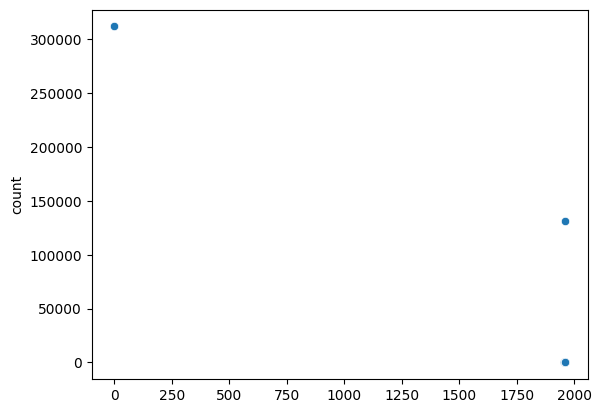

In [24]:
fig2 = sns.scatterplot(abs(df_weather["pressure_air"] - df_weather["pressure_station_level"]).value_counts())

#### Air Temperature
- slight differences in three different columns 
- maybe different measurement heights?
- sometimes missing values in two of the three columns

In [25]:
print((df_weather["temp_air"] == df_weather["temp_air2"]).value_counts())

True     362062
False    212965
Name: count, dtype: int64


In [26]:
df_weather[~(df_weather["temp_air"].isna() | df_weather["temp_air2"].isna()) &\
           (df_weather["temp_air"] - df_weather["temp_air2"]) != 0]\
          [["date", "temp_air", "temp_air2", "temp_air_2m"]]

,date,temp_air,temp_air2,temp_air_2m
34758,1971-01-01 06:00:00,-9.0,-8.7,-9.0
34759,1971-01-01 09:00:00,-8.0,-8.9,-8.0
34760,1971-01-01 12:00:00,-6.0,-7.1,-6.0
34761,1971-01-01 15:00:00,-6.0,-5.2,-6.0
34763,1971-01-01 21:00:00,-7.0,-7.2,-7.0
...,...,...,...,...
574494,1989-06-24 06:00:00,-999.0,13.5,NaN
574495,1989-07-09 02:00:00,-999.0,17.5,NaN
574509,1989-12-21 06:00:00,-999.0,9.8,NaN
574683,1992-12-23 12:00:00,-999.0,2.0,NaN


#### Relative Humidity

- varying differences
- sometimes one of the column has missing values (-999)

In [27]:
# relative humidity
print((df_weather["humidity_rel"] == df_weather["rel_humidity"]).value_counts())
df_weather[df_weather["humidity_rel"] != df_weather["rel_humidity"]][["humidity_rel", "rel_humidity"]].value_counts()

False    527250
True      47777
Name: count, dtype: int64


humidity_rel  rel_humidity
 98.0         97.9            2706
              100.0           1914
 99.0         99.3            1854
 97.0         97.2            1832
 98.0         97.8            1740
                              ... 
 74.0         59.4               1
              59.0               1
              57.7               1
              37.5               1
-999.0        38.7               1
Name: count, Length: 14780, dtype: int64

In [28]:
df_weather[abs(df_weather["humidity_rel"] - df_weather["rel_humidity"])>800][["humidity_rel", "rel_humidity"]]

,humidity_rel,rel_humidity
133011,-999.0,80.9
133012,-999.0,78.8
133013,-999.0,68.6
133014,-999.0,57.5
133015,-999.0,55.0
...,...,...
443028,-999.0,81.7
443029,-999.0,80.0
448498,-999.0,52.8
448499,-999.0,46.8


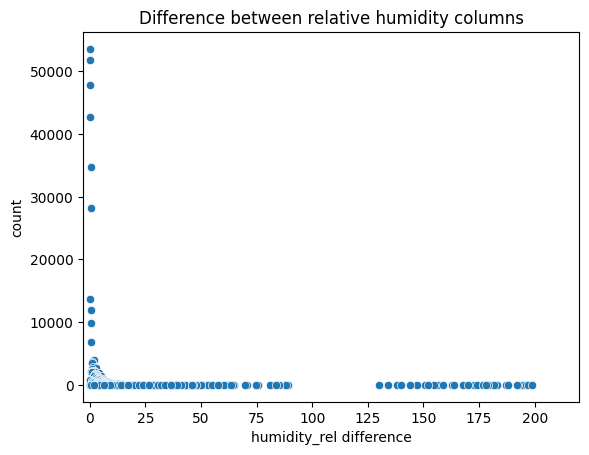

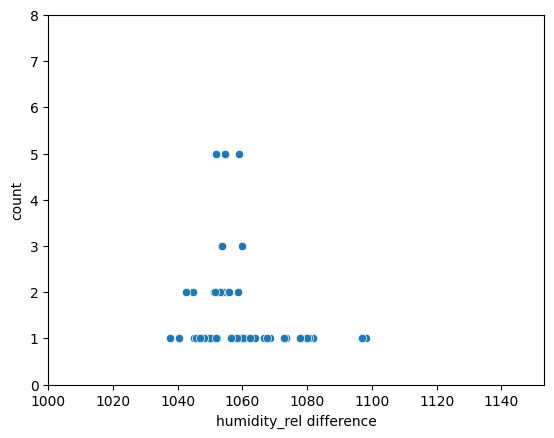

In [29]:
# plotting
fig = sns.scatterplot(abs(df_weather["humidity_rel"] - df_weather["rel_humidity"]).value_counts())
fig.set_xlabel("humidity_rel difference")
fig.set_xlim(-3, 220)
fig.set_title("Difference between relative humidity columns")
plt.show()
fig2 = sns.scatterplot(abs(df_weather["humidity_rel"] - df_weather["rel_humidity"]).value_counts())
fig2.set_xlabel("humidity_rel difference")
fig2.set_xlim(1000, None)
fig2.set_ylim(0, 8)
plt.show()
# differ in rounding


#### Dew Point Temperature

- many points identical, but also many differ

In [30]:
print((df_weather["temp_dew_point"] == df_weather["dew_point_2m"]).value_counts(), "\n")
print(df_weather[df_weather["temp_dew_point"] != df_weather["dew_point_2m"]][["temp_dew_point", "dew_point_2m"]].value_counts())
# differ only in missing value encoding

True     445188
False    129839
Name: count, dtype: int64 

temp_dew_point  dew_point_2m
-999.0           0.0            167
                -99.9            13
 16.2           -99.9             2
 3.6            -99.9             2
 19.0           -99.9             1
 12.3           -99.9             1
 9.6            -99.9             1
 9.9            -99.9             1
 10.0           -99.9             1
 10.9           -99.9             1
 11.2           -99.9             1
 12.2           -99.9             1
 12.6           -99.9             1
 17.2           -99.9             1
 9.3            -99.9             1
 14.9           -99.9             1
 15.9           -99.9             1
 16.0           -99.9             1
 16.3           -99.9             1
 13.6           -99.9             1
 8.3            -99.9             1
 8.4            -99.9             1
 8.2            -99.9             1
 1.9            -99.9             1
 2.0            -99.9             1
 2.3       

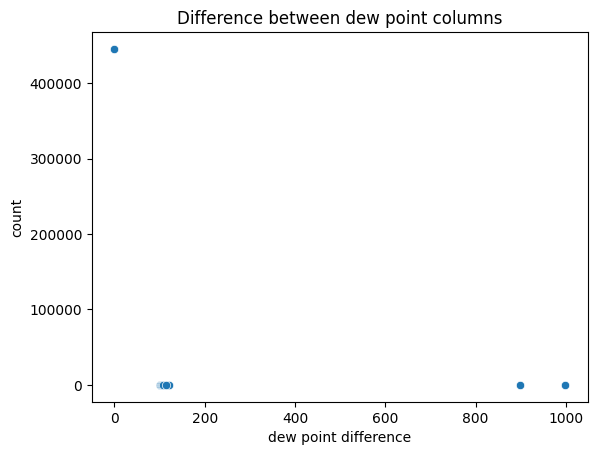

In [31]:
# plotting
fig = sns.scatterplot(abs(df_weather["temp_dew_point"] - df_weather["dew_point_2m"]).value_counts())
fig.set_xlabel("dew point difference")
# fig.set_xlim(-3, 220)
fig.set_title("Difference between dew point columns")
plt.show()

#### Sunshine Duration

- some values identical, others not
- many missing values

In [32]:
df_weather.iloc[81296:81320][["date", "sunshine_duration", "sunshine_duration_lberg"]]

,date,sunshine_duration,sunshine_duration_lberg
81296,1981-11-03 04:00:00,0.0,0.0
81297,1981-11-03 05:00:00,0.0,0.0
81298,1981-11-03 06:00:00,0.0,0.0
81299,1981-11-03 07:00:00,0.0,0.0
81300,1981-11-03 08:00:00,0.0,0.0
81301,1981-11-03 09:00:00,0.0,0.0
81302,1981-11-03 10:00:00,0.0,0.0
81303,1981-11-03 11:00:00,42.0,42.0
81304,1981-11-03 12:00:00,60.0,60.0
81305,1981-11-03 13:00:00,60.0,60.0


In [33]:
# compare columns dealing with sunshine duration 
# might be duplicate
print((df_weather["sunshine_duration"] == df_weather["sunshine_duration_lberg"]).value_counts())
df_weather[~(df_weather["sunshine_duration"].isna() | df_weather["sunshine_duration_lberg"].isna()) &\
           (df_weather["sunshine_duration"] - df_weather["sunshine_duration_lberg"]) != 0]\
          [["date", "sunshine_duration", "sunshine_duration_lberg"]]
# values differ clearly


False    323160
True     251867
Name: count, dtype: int64


,date,sunshine_duration,sunshine_duration_lberg
81309,1981-11-03 17:00:00,30.0,0.0
81874,1981-11-27 07:00:00,12.0,0.0
85725,1982-05-07 19:00:00,6.0,0.0
99394,1983-12-02 07:00:00,6.0,0.0
145302,1989-03-04 09:00:00,30.0,48.0
...,...,...,...
574923,2000-08-19 08:00:00,43.0,42.0
574927,2000-09-25 11:00:00,52.0,53.0
574932,2000-11-01 16:00:00,22.0,23.0
574937,2001-01-03 08:00:00,33.0,31.0


In [34]:
# number of NaNs
print("%d NaNs in columns sunshine_duration_lberg" % df_weather["sunshine_duration_lberg"].isna().value_counts()[True])
print("%d NaNs in columns sunshine_duration" % df_weather["sunshine_duration"].isna().value_counts()[True])

167459 NaNs in columns sunshine_duration_lberg
242672 NaNs in columns sunshine_duration


In [35]:
# more NaNs
print(((df_weather["sunshine_duration"] - df_weather["sunshine_duration_lberg"]) > 60).sum(), "more missing values (-999)")
df_weather[(df_weather["sunshine_duration"] - df_weather["sunshine_duration_lberg"]) > 60]\
          [["date", "sunshine_duration", "sunshine_duration_lberg"]].head()

558 more missing values (-999)


,date,sunshine_duration,sunshine_duration_lberg
185190,1993-10-01 06:00:00,0.0,-999.0
185191,1993-10-01 07:00:00,0.0,-999.0
185192,1993-10-01 08:00:00,48.0,-999.0
185193,1993-10-01 09:00:00,60.0,-999.0
185194,1993-10-01 10:00:00,54.0,-999.0


Text(0.5, 1.0, 'Difference between sunshine duration columns')

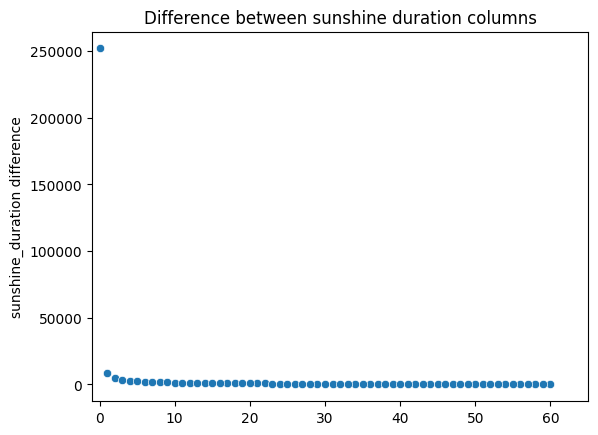

In [36]:
fig = sns.scatterplot(abs(df_weather["sunshine_duration"] - df_weather["sunshine_duration_lberg"]).value_counts())
fig.set_ylabel("sunshine_duration difference")
fig.set_xlim(-1, 65)
fig.set_title("Difference between sunshine duration columns")

## Result: Full Dataframe

In [37]:
print(df_weather.shape)
print(df_weather.columns)

(575027, 55)
Index(['date', 'cloud_cover', 'cloud_type_layer1', 'cloud_type_layer1_abbrev',
       'cloud_lower_boundary_height_layer1', 'cloud_cover_layer1',
       'cloud_type_layer2', 'cloud_type_layer2_abbrev',
       'cloud_lower_boundary_height_layer2', 'cloud_cover_layer2',
       'cloud_type_layer3', 'cloud_type_layer3_abbrev',
       'cloud_lower_boundary_height_layer3', 'cloud_cover_layer3',
       'cloud_type_layer4', 'cloud_type_layer4_abbrev',
       'cloud_lower_boundary_height_layer4', 'cloud_cover_layer4',
       'temp_soil_002cm', 'temp_soil_005cm', 'temp_soil_010cm',
       'temp_soil_020cm', 'temp_soil_050cm', 'temp_soil_100cm', 'wind_speed',
       'wind_direct', 'wind_gust', 'wind_speed_synopsis',
       'wind_direct_synopsis', 'cloud_cover_y', 'pressure_sea_level',
       'pressure_station_level', 'precipitation_height', 'precipitation_form',
       'sunshine_duration', 'radiation_longwave', 'radiation_sum_diffuse',
       'radiation_shortwave', 'sunshine_duration

In [38]:
# save table as file
df_weather.to_csv("../data/weather/dwd_hourly_station%s_full.csv" % target_dwd_weather_station_id)

## Result: Filtered Dataframe

- filter irrelevant columns

In [39]:
info_columns = list(df_weather.columns[df_weather.columns.str.contains('soil', case=False)])
print("Dropping %d soil columns: %s" % (len(info_columns), ", ".join(info_columns)))
df_weather.drop(columns=info_columns, inplace=True)


Dropping 6 soil columns: temp_soil_002cm, temp_soil_005cm, temp_soil_010cm, temp_soil_020cm, temp_soil_050cm, temp_soil_100cm


In [40]:
info_columns = list(df_weather.columns[df_weather.columns.str.contains('layer', case=False)])
print("Dropping %d cloud layer columns: %s" % (len(info_columns), ", ".join(info_columns)))
df_weather.drop(columns=info_columns, inplace=True)

Dropping 16 cloud layer columns: cloud_type_layer1, cloud_type_layer1_abbrev, cloud_lower_boundary_height_layer1, cloud_cover_layer1, cloud_type_layer2, cloud_type_layer2_abbrev, cloud_lower_boundary_height_layer2, cloud_cover_layer2, cloud_type_layer3, cloud_type_layer3_abbrev, cloud_lower_boundary_height_layer3, cloud_cover_layer3, cloud_type_layer4, cloud_type_layer4_abbrev, cloud_lower_boundary_height_layer4, cloud_cover_layer4


In [41]:
df_weather.weather_code.value_counts()


weather_code
-1.0      173773
 0.0       41079
 10.0      36685
 2.0       25651
 61.0      17000
           ...  
 32.0          1
 31.0          1
 35.0          1
 9.0           1
 166.0         1
Name: count, Length: 137, dtype: int64

In [42]:
df_weather.weather_descript.value_counts()

weather_descript
Wetter wurde nicht gemeldet                                                                                                      173773
Änderung des Bewölkungszustandes (keine Meteore oder Photometeore): Wolkenentwicklung nicht beobachtet oder nicht beobachtbar     41079
Feuchter Dunst (Sichtweite 1 km bis < 8 km, Relative Feuchte >= 80%)                                                              36685
Änderung des Bewölkungszustandes (keine Meteore oder Photometeore): wolkenlos oder Bewölkungszustand im ganzen unverändert        25651
Regen ohne Unterbrechungen: leicht                                                                                                17000
                                                                                                                                  ...  
Staub- oder Sandsturm, in der letzten Stunde begonnen oder stärker geworden: stark                                                    1
Staub- oder Sandsturm, in der l

In [43]:
info_columns = list(df_weather.columns[df_weather.columns.str.contains('weather', case=False)])
print("Dropping %d weather decription columns: %s" % (len(info_columns), ", ".join(info_columns)))
df_weather.drop(columns=info_columns, inplace=True)

Dropping 2 weather decription columns: weather_code, weather_descript


In [44]:
print(df_weather.shape)
print(df_weather.columns)


(575027, 31)
Index(['date', 'cloud_cover', 'wind_speed', 'wind_direct', 'wind_gust',
       'wind_speed_synopsis', 'wind_direct_synopsis', 'cloud_cover_y',
       'pressure_sea_level', 'pressure_station_level', 'precipitation_height',
       'precipitation_form', 'sunshine_duration', 'radiation_longwave',
       'radiation_sum_diffuse', 'radiation_shortwave',
       'sunshine_duration_lberg', 'zenit', 'date_solar_time', 'temp_air',
       'temp_dew_point', 'abs_humidity', 'vapor_pressure', 'temp_humid',
       'pressure_air', 'temp_air_2m', 'rel_humidity', 'dew_point_2m',
       'temp_air2', 'humidity_rel', 'vis_range'],
      dtype='object')


In [45]:
# save table as file
df_weather.to_csv("../data/weather/dwd_hourly_station%s_filtered.csv" % target_dwd_weather_station_id)

# Check Date Column

- potential issue of daylight savings time - might lead to duplicates and gaps
- approx 8200 values dropped - slightly less than a year (as was found for the daily data) - sounds reasonable

In [46]:
df_weather = df_weather.sort_values(by="date")

In [47]:
# dates are unique (only 143907 without full join)
df_weather.date.value_counts().value_counts()

count
1    575027
Name: count, dtype: int64

In [48]:
sorted(df_weather.date.unique())[-20:]

[Timestamp('2023-07-26 04:00:00'),
 Timestamp('2023-07-26 05:00:00'),
 Timestamp('2023-07-26 06:00:00'),
 Timestamp('2023-07-26 07:00:00'),
 Timestamp('2023-07-26 08:00:00'),
 Timestamp('2023-07-26 09:00:00'),
 Timestamp('2023-07-26 10:00:00'),
 Timestamp('2023-07-26 11:00:00'),
 Timestamp('2023-07-26 12:00:00'),
 Timestamp('2023-07-26 13:00:00'),
 Timestamp('2023-07-26 14:00:00'),
 Timestamp('2023-07-26 15:00:00'),
 Timestamp('2023-07-26 16:00:00'),
 Timestamp('2023-07-26 17:00:00'),
 Timestamp('2023-07-26 18:00:00'),
 Timestamp('2023-07-26 19:00:00'),
 Timestamp('2023-07-26 20:00:00'),
 Timestamp('2023-07-26 21:00:00'),
 Timestamp('2023-07-26 22:00:00'),
 Timestamp('2023-07-26 23:00:00')]

In [49]:
# check time steps
df_weather.date.diff().value_counts()

date
0 days 01:00:00    561647
0 days 03:00:00     10508
0 days 12:00:00      2604
0 days 06:00:00       133
0 days 15:00:00       108
0 days 18:00:00        14
0 days 21:00:00         9
0 days 09:00:00         1
1 days 00:00:00         1
1 days 15:00:00         1
Name: count, dtype: int64

In [50]:
sorted(df_weather.date.diff().dt.components['days'].unique())

[nan, 0.0, 1.0]

[Text(0.5, 1.0, 'Day difference between measurements')]

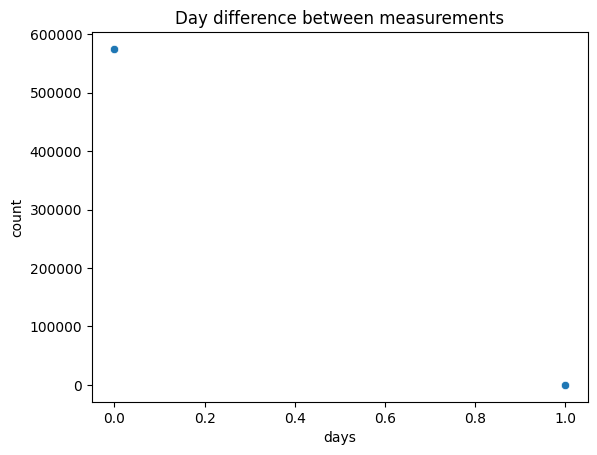

In [51]:
sns.scatterplot(df_weather.date.diff().dt.components['days'].value_counts()).set(title="Day difference between measurements")

In [52]:
df_weather.date.diff().dt.components['hours'].value_counts()


hours
1.0     561647
3.0      10508
12.0      2604
6.0        133
15.0       109
18.0        14
21.0         9
9.0          1
0.0          1
Name: count, dtype: int64

<Axes: xlabel='hours', ylabel='count'>

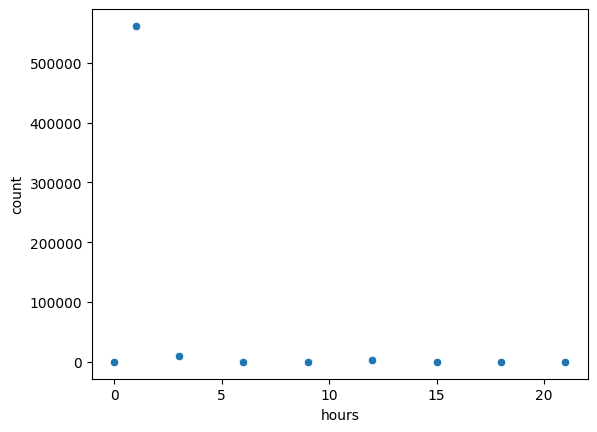

In [53]:
sns.scatterplot(df_weather.date.diff().dt.components['hours'].value_counts())


In [54]:
# check timesteps of recent data only (as ancient data has not been measured that often)
df_weather[-2000:].date.diff().value_counts()


date
0 days 01:00:00    1999
Name: count, dtype: int64

In [55]:
# check timesteps of recent data only (as ancient data has not been measured that often)
df_weather[-2000:].date.diff().dt.components['hours'].value_counts()


hours
1.0    1999
Name: count, dtype: int64

In [56]:
df_weather[df_weather.date.diff().dt.components['hours']==6.0].date.tail()

959      1952-09-07 18:00:00
993      1952-09-14 18:00:00
1025     1952-09-21 12:00:00
1026     1952-09-21 18:00:00
448530   1959-07-01 00:00:00
Name: date, dtype: datetime64[ns]

In [57]:
df_weather[df_weather.date.diff().dt.components['hours']==3.0].date.tail()

13368   1959-06-29 18:00:00
13370   1959-06-30 09:00:00
13371   1959-06-30 12:00:00
13372   1959-06-30 15:00:00
13373   1959-06-30 18:00:00
Name: date, dtype: datetime64[ns]


## Notes

- multiple columns for some of the features  
  (sometimes differing only in distribution of NaNs, sometimes values differ)
    - sunshine duration
    - dew point temperature
    - air temperature (3 columns)
    - air pressure
    - relative humidity
- recommendation:
    - filter by date first and then check columns again  
      (e.g. some may be only NaN in old data)
>
- regarding timestamp
    - no apparent issues acc. to daylight savings time
    - but: sometimes larger gaps (3h, 6h, ...) - particularly for old data
  
- maybe later: add categorical column for "Wetter wurde nicht gemeldet" (weather not reported)